In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

In [ ]:
train = data_df.sample(frac=0.8, random_state=42)
test = data_df.drop(train.index)
val = test.sample(frac=0.5, random_state=42)
test = test.drop(val.index)
print(train.shape, test.shape, val.shape)

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])


transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])


transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [ ]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform_train)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)

In [ ]:
print(train.iloc[2, 0])

In [ ]:
train_dataset.__getitem__(2)

In [ ]:
label_encoder.inverse_transform([0])

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [ ]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 20

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.4)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 256)
    self.dropout2 = nn.Dropout(0.4)
    self.output = nn.Linear(256, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.pooling(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)
    x = self.pooling(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.relu(x)
    x = self.dropout2(x)
    x = self.output(x)

    return x

In [ ]:
model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 5

for epoch in range(EPOCHS):
    model.train()
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()
        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()

    model.eval()
    total_loss_val = 0
    total_acc_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()
            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    avg_val_loss = total_loss_val / 1000
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping di epoch {epoch+1}")
            break

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
    total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

    print(f'''Epoch {epoch+1}/{EPOCHS},
        Train Loss: {round(total_loss_train/1000, 4)} | Train Acc: {round((total_acc_train/train_dataset.__len__())*100, 4)}%
        Val Loss:   {round(total_loss_val/1000, 4)} | Val Acc:   {round((total_acc_val/val_dataset.__len__())*100, 4)}%
    ''')

model.load_state_dict(torch.load('best_model.pth'))
print("Model terbaik berhasil di-load!")

Epoch 1/10,
            Train Loss: 0.3295 Train Accuracy 81.0291
            Validation Loss 0.0362 Validation Accuracy 91.5289
        
Epoch 2/10,
            Train Loss: 0.1386 Train Accuracy 92.7464
            Validation Loss 0.0252 Validation Accuracy 94.3802
        
Epoch 3/10,
            Train Loss: 0.0851 Train Accuracy 95.5894
            Validation Loss 0.0189 Validation Accuracy 95.7851
        
Epoch 4/10,
            Train Loss: 0.0605 Train Accuracy 96.9976
            Validation Loss 0.0197 Validation Accuracy 95.6198
        
Epoch 5/10,
            Train Loss: 0.0451 Train Accuracy 97.7327
            Validation Loss 0.0186 Validation Accuracy 95.7851
        
Epoch 6/10,
            Train Loss: 0.0339 Train Accuracy 98.3172
            Validation Loss 0.0182 Validation Accuracy 96.5289
        
Epoch 7/10,
            Train Loss: 0.0246 Train Accuracy 98.8398
            Validation Loss 0.0196 Validation Accuracy 95.9917
        
Epoch 8/10,
            Train Loss

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 95.9901 and Loss is 0.0205


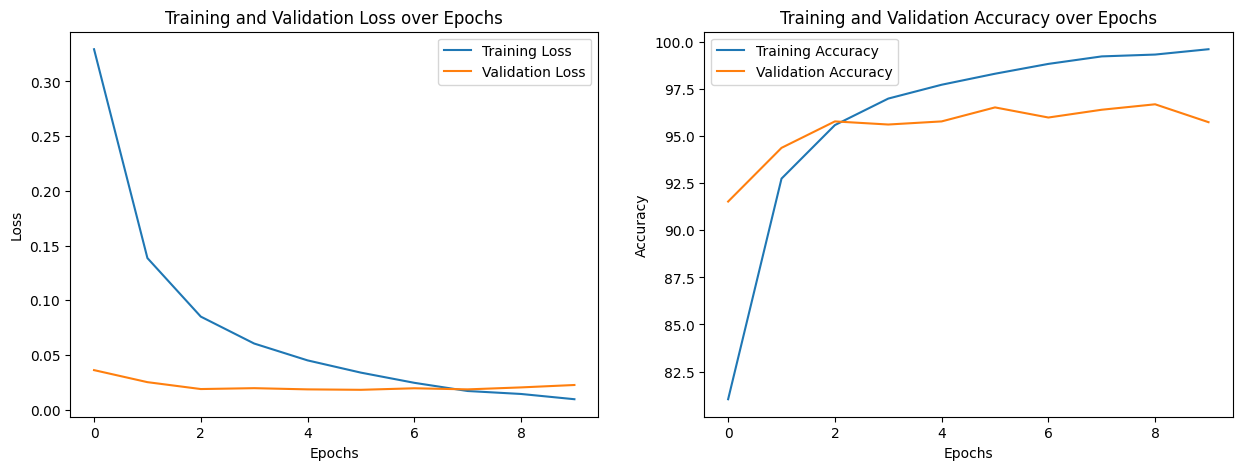

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [38]:
predict_image("/content/cat.jpg")

array(['cat'], dtype=object)